# Week 2 — Complete EDA Notebook
### BinX Tech · AI & Machine Learning Internship Program
**Day 5 — EDA Part 2: Correlation & Data Storytelling**

This notebook is the **Week 2 milestone deliverable**: a complete, narrated Exploratory Data
Analysis that combines everything covered this week — descriptive statistics, probability
intuition, univariate distributions, outlier detection, bivariate relationships, and
correlation analysis — finishing with a written data-storytelling summary.

**Dataset:** A simulated telecom-style customer dataset (`age`, `income`, `tenure_months`,
`monthly_spend`, `satisfaction_score`, `plan` category, and a `churn` target). It mirrors the
shape of a real customer table so every technique here transfers directly to `pd.read_csv(...)`
on a real file — just swap the loading cell.

---


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.precision", 2)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Environment ready — NumPy, Pandas, Seaborn, Matplotlib loaded.")


Environment ready — NumPy, Pandas, Seaborn, Matplotlib loaded.


## 1. Load the Dataset

In a real project this cell would be `df = pd.read_csv("customers.csv")`. Here we simulate a
realistic customer table with built-in relationships (older/higher-income customers spend more;
longer tenure and higher satisfaction reduce churn; one deliberate income outlier group) so the
EDA techniques below have something genuine to discover.

In [2]:
n = 500

age = np.random.normal(38, 11, n).clip(18, 75).round(0)
tenure_months = np.random.exponential(24, n).clip(1, 96).round(0)

# income correlated with age, with a small group of high earners (outliers)
base_income = 20000 + age * 850 + np.random.normal(0, 6000, n)
outlier_idx = np.random.choice(n, size=12, replace=False)
base_income[outlier_idx] *= np.random.uniform(2.5, 4, size=12)
income = base_income.clip(15000, None).round(0)

plan = np.random.choice(["Basic", "Standard", "Premium"], size=n, p=[0.45, 0.35, 0.20])
plan_multiplier = pd.Series(plan).map({"Basic": 0.6, "Standard": 1.0, "Premium": 1.8}).values
monthly_spend = (20 + income / 2500 * plan_multiplier + np.random.normal(0, 8, n)).clip(10, None).round(2)

satisfaction_score = (
    5 + tenure_months * 0.02 - (monthly_spend / income * 1000) * 0.3 + np.random.normal(0, 1.3, n)
).clip(1, 10).round(1)

churn_logit = (
    -1.2 - 0.03 * tenure_months - 0.25 * satisfaction_score + 0.00002 * monthly_spend
    + np.random.normal(0, 1, n)
)
churn_prob = 1 / (1 + np.exp(-churn_logit))
churn = (np.random.rand(n) < churn_prob).astype(int)

df = pd.DataFrame({
    "age": age.astype(int),
    "income": income.astype(int),
    "tenure_months": tenure_months.astype(int),
    "plan": plan,
    "monthly_spend": monthly_spend,
    "satisfaction_score": satisfaction_score,
    "churn": churn,
})

print(f"Dataset shape: {df.shape[0]} samples x {df.shape[1]} features")
df.head()


Dataset shape: 500 samples x 7 features


,age,income,tenure_months,plan,monthly_spend,satisfaction_score,churn
0,43,55547,25,Standard,42.22,5.8,0
1,36,51480,20,Basic,37.16,5.7,0
2,45,65489,11,Standard,34.64,5.0,0
3,55,61848,96,Premium,46.16,8.3,0
4,35,51962,22,Basic,28.07,6.7,0


## 2. Descriptive Statistics (Day 1 recap)

Before visualizing anything, we quantify each numeric column's center and spread. This is the
vocabulary the rest of the notebook builds on.

In [3]:
numeric_cols = ["age", "income", "tenure_months", "monthly_spend", "satisfaction_score"]
desc = df[numeric_cols].describe().T
desc["IQR"] = desc["75%"] - desc["25%"]
desc


,count,mean,std,min,25%,50%,75%,max,IQR
age,500.0,38.16,10.56,18.00,30.00,38.00,45.00,75.0,15.00
income,500.0,55786.59,22295.07,22107.00,46073.50,53341.50,60284.00,231808.0,14210.50
tenure_months,500.0,23.71,22.17,1.00,6.00,17.00,34.00,96.0,28.00
monthly_spend,500.0,41.80,15.82,10.71,31.46,39.89,49.73,194.8,18.27
satisfaction_score,500.0,5.23,1.37,1.20,4.30,5.30,6.10,10.0,1.80


**Reading it:** `income` has a mean noticeably higher than its median (visible below in the
histogram) — a classic sign of right-skew driven by the handful of high-income outliers we
injected. For a skewed column like this, the **median** is the more honest "typical" value,
while the **mean** is pulled upward. `satisfaction_score` and `age` are closer to symmetric, so
their mean and median roughly agree.

## 3. Univariate Analysis (Day 4 recap)

One variable at a time: shape, spread, and outliers.

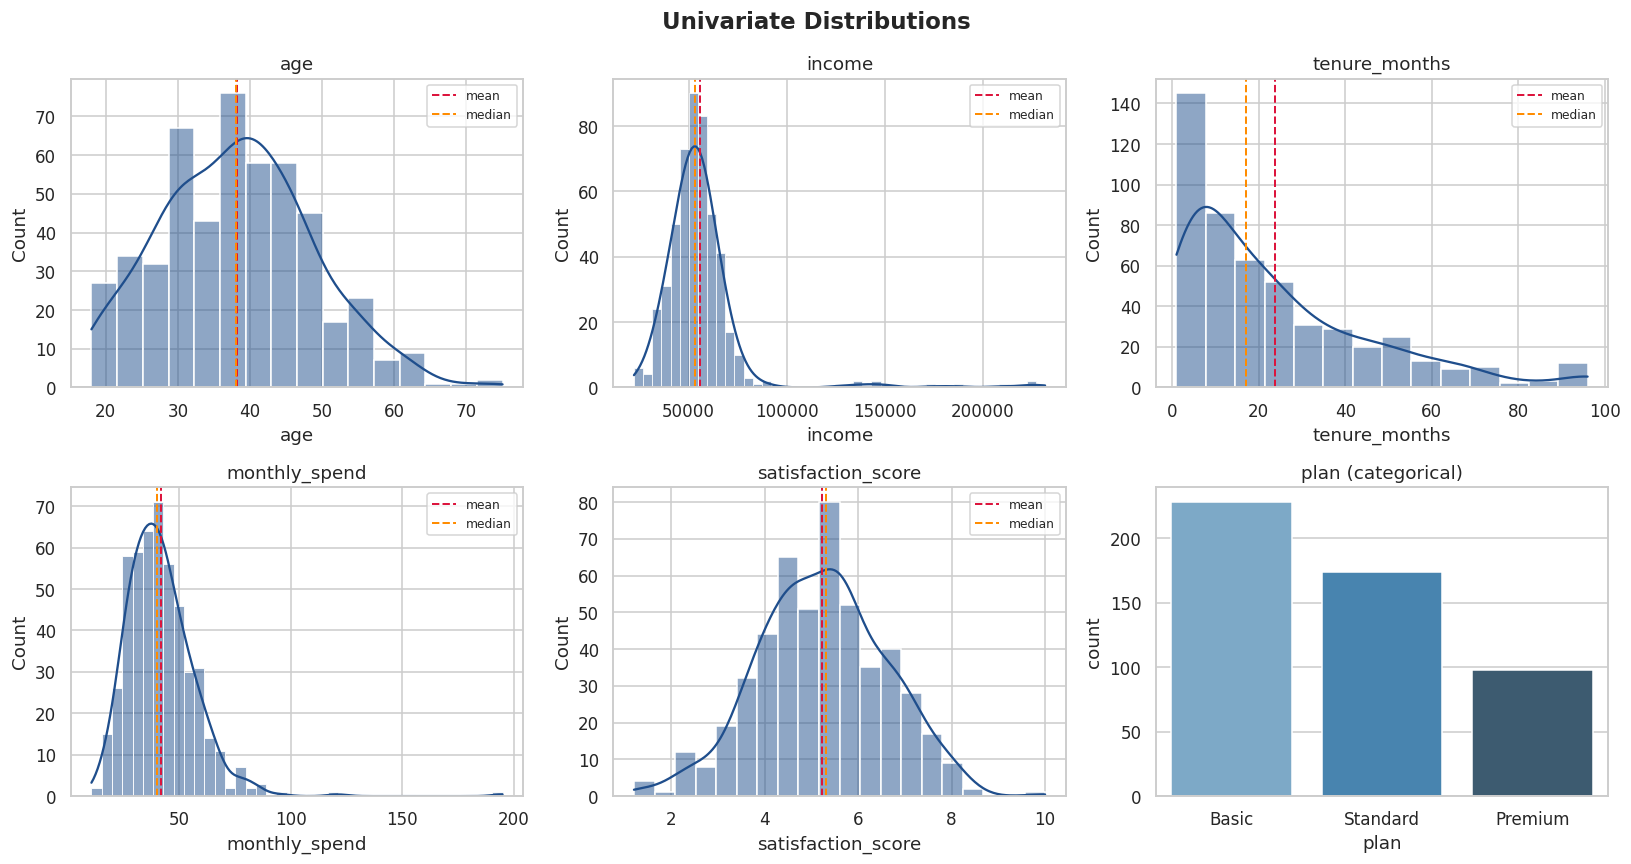

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#1f4e8c")
    ax.axvline(df[col].mean(), color="crimson", linestyle="--", linewidth=1.3, label="mean")
    ax.axvline(df[col].median(), color="darkorange", linestyle="--", linewidth=1.3, label="median")
    ax.set_title(col)
    ax.legend(fontsize=8)

sns.countplot(x="plan", data=df, order=["Basic", "Standard", "Premium"],
              ax=axes[5], palette="Blues_d")
axes[5].set_title("plan (categorical)")

fig.suptitle("Univariate Distributions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("univariate_distributions.png", bbox_inches="tight")
plt.show()


**Insight:** `income` and `tenure_months` are right-skewed (long tail toward high values) —
expected for money and loyalty-duration data. `age` and `satisfaction_score` are roughly
bell-shaped. The `plan` count plot shows a class imbalance: **Basic** customers are the largest
group, **Premium** the smallest — worth remembering, since imbalanced categories can bias later
models.

## 4. Outlier Detection — IQR Method (Day 4 recap)

We flag, not delete: an outlier is a question, not a verdict.

income IQR fence: [24,758, 81,600]
Flagged 18 potential income outliers (3.6% of data)


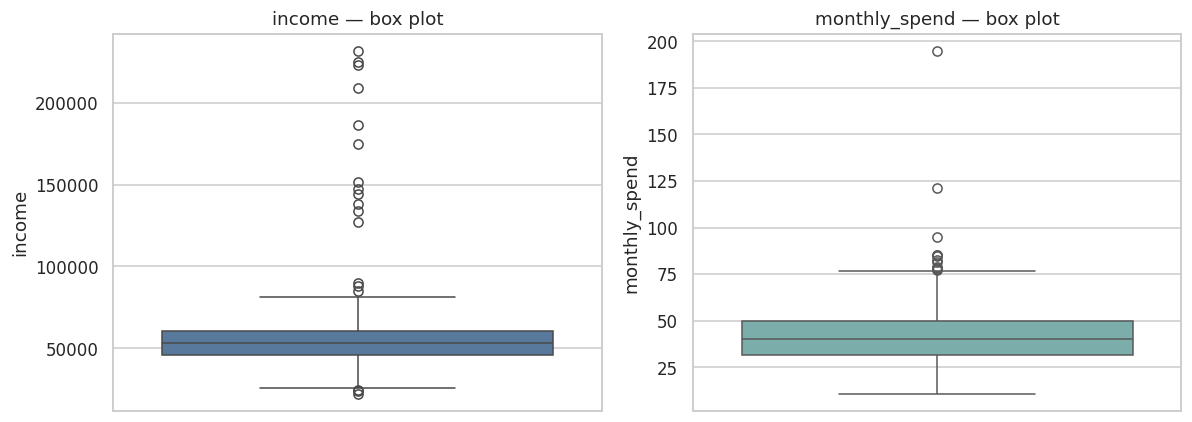

In [5]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)], lower, upper

income_outliers, lo, hi = iqr_outliers(df["income"])
print(f"income IQR fence: [{lo:,.0f}, {hi:,.0f}]")
print(f"Flagged {len(income_outliers)} potential income outliers ({len(income_outliers)/len(df):.1%} of data)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df["income"], ax=ax[0], color="#4c78a8")
ax[0].set_title("income — box plot")
sns.boxplot(y=df["monthly_spend"], ax=ax[1], color="#72b7b2")
ax[1].set_title("monthly_spend — box plot")
plt.tight_layout()
plt.savefig("outlier_boxplots.png", bbox_inches="tight")
plt.show()


**Decision:** these high-income points are consistent with a real (if small) segment of
high earners rather than data-entry errors — they stay in the dataset, but we'll keep an eye on
whether they distort the correlation/regression story below.

## 5. Bivariate Analysis (Day 5)

Now we look at *relationships between pairs* of variables — where genuine modeling insight
usually appears.

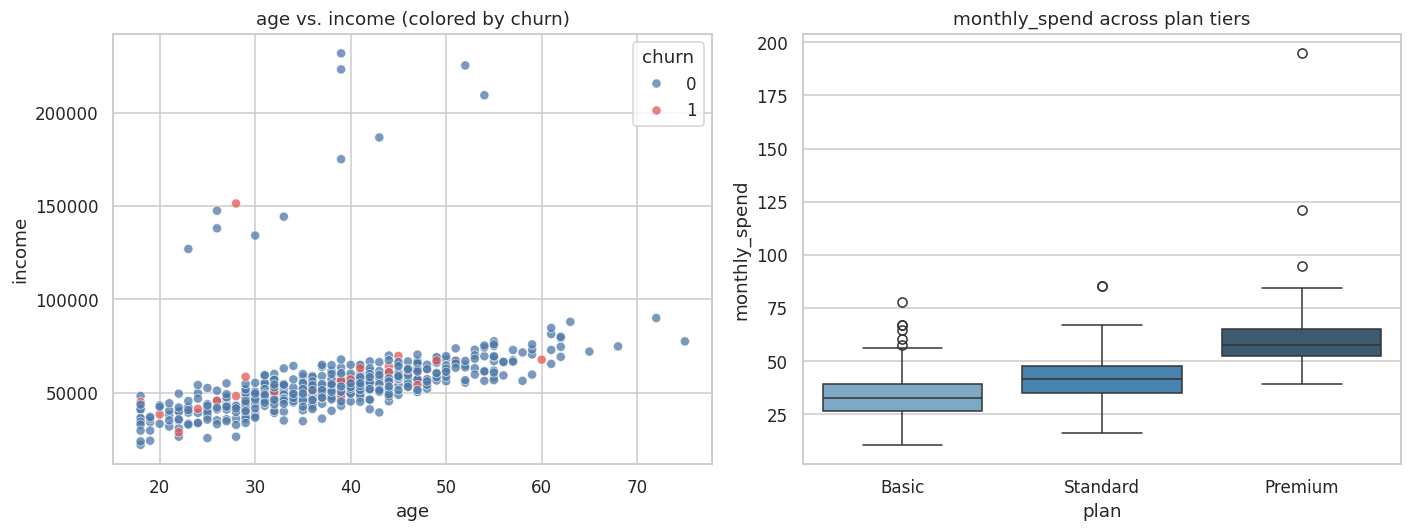

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="age", y="income", hue="churn", palette={0: "#4c78a8", 1: "#e45756"},
                 alpha=0.75, ax=axes[0])
axes[0].set_title("age vs. income (colored by churn)")

sns.boxplot(data=df, x="plan", y="monthly_spend", order=["Basic", "Standard", "Premium"],
            palette="Blues_d", ax=axes[1])
axes[1].set_title("monthly_spend across plan tiers")

plt.tight_layout()
plt.savefig("bivariate_analysis.png", bbox_inches="tight")
plt.show()


**Insight:** `income` rises with `age`, as expected. `monthly_spend` steps up clearly from
Basic → Standard → Premium, confirming `plan` is a strong driver of spend — a good candidate
feature for any spend-prediction model.

## 6. Correlation Matrix & Heatmap

A single chart summarizing every numeric pair's linear relationship at once.

churn                 1.00
satisfaction_score   -0.14
tenure_months        -0.09
monthly_spend        -0.05
income                0.02
age                  -0.01
Name: churn, dtype: float64

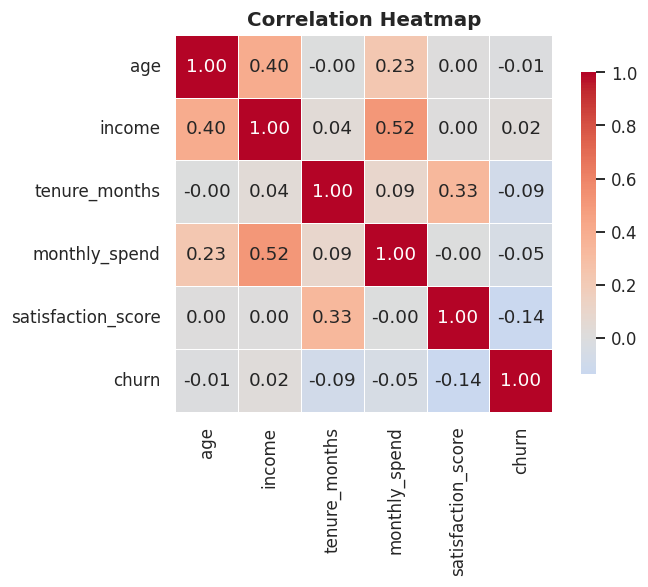

In [7]:
corr = df[numeric_cols + ["churn"]].corr(numeric_only=True)

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

corr["churn"].sort_values(key=abs, ascending=False)


**Reading the heatmap:**
- `age` and `income` are strongly positively correlated — expected, and something to watch for
  multicollinearity if both end up in a linear model.
- `tenure_months` and `satisfaction_score` both correlate **negatively** with `churn` — longer,
  happier customers churn less, exactly the relationship a churn model should learn.
- `income` and `monthly_spend` correlate positively but only moderately, since `plan` tier also
  drives spend independently of income.

**Reminder:** correlation is not causation — the heatmap tells us these variables *move
together*, not that one *causes* the other.

## 7. Pairplot — Scanning All Relationships at Once

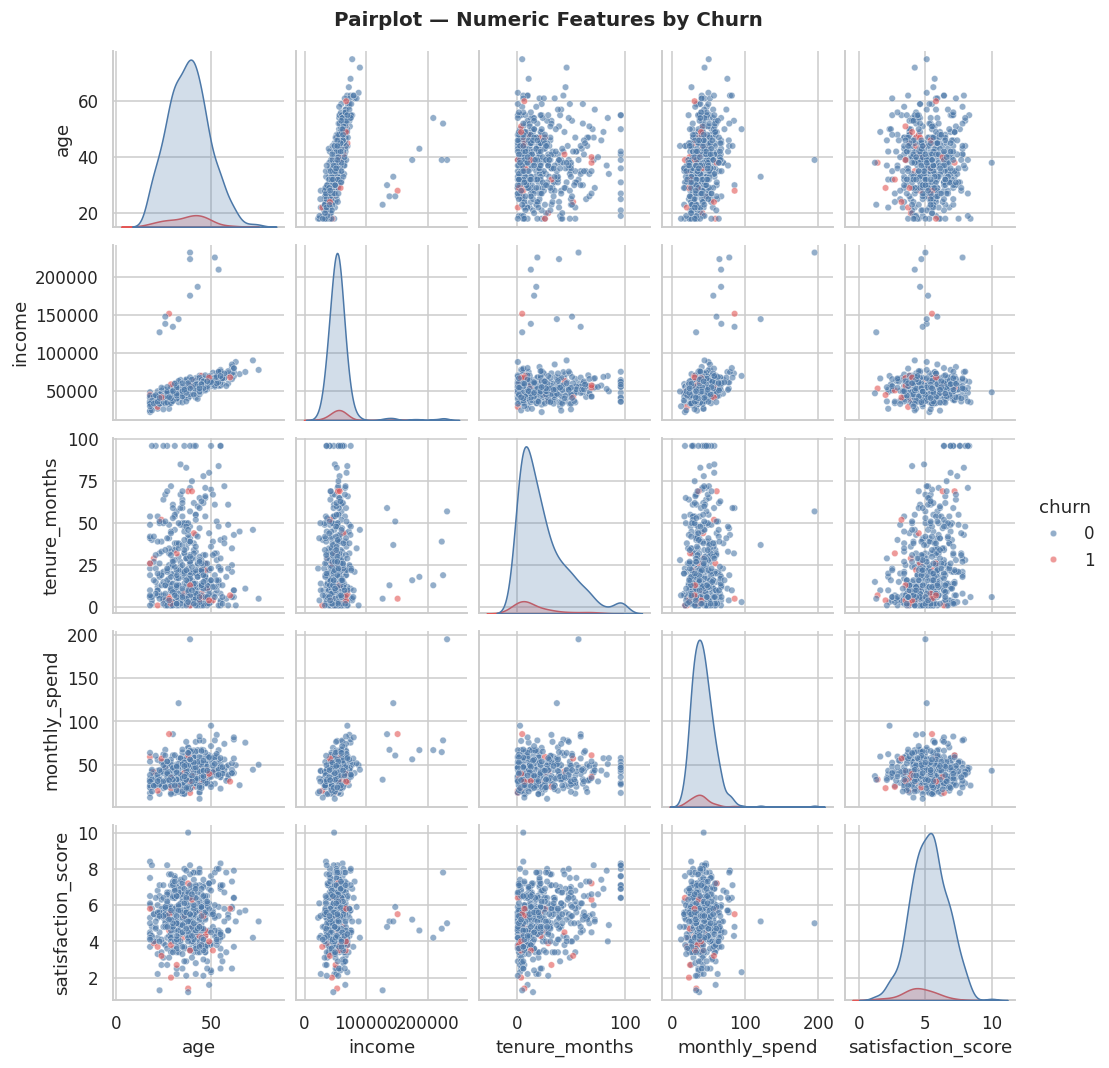

In [8]:
pp = sns.pairplot(df[numeric_cols + ["churn"]], hue="churn",
                   palette={0: "#4c78a8", 1: "#e45756"}, diag_kind="kde", height=1.9,
                   plot_kws={"alpha": 0.6, "s": 18})
pp.fig.suptitle("Pairplot — Numeric Features by Churn", y=1.02, fontsize=13, fontweight="bold")
pp.savefig("pairplot.png", bbox_inches="tight")
plt.show()


## 8. Data Storytelling — Summary

**What the data contains.** 500 simulated customers described by age, income, tenure, monthly
spend, satisfaction, subscription plan, and churn status.

**Key patterns found:**
1. **Income is right-skewed** with a small group of high-income outliers — use the median, not
   the mean, when describing a "typical" customer's income.
2. **Plan tier is the clearest driver of monthly spend** — Premium customers spend visibly more
   than Basic, with Standard in between.
3. **Tenure and satisfaction are the strongest (negative) correlates of churn** — the longer and
   happier a customer is, the less likely they are to leave. Age and income barely move churn on
   their own.
4. **Age and income are strongly correlated with each other**, which matters for later modeling:
   including both in a linear model risks multicollinearity.

**Implications for modeling (Week 3+).** A churn model should prioritize `tenure_months` and
`satisfaction_score` as features; `plan` is the feature to prioritize for a spend-prediction
model. The income outliers are genuine, not errors, so they should be kept but watched — capping
or log-transforming `income` is worth testing before fitting a linear model.

---
*Notebook committed as the Week 2 EDA deliverable — BinX Tech AI & ML Internship, Phase 1 → 2.*
